<a href="https://colab.research.google.com/github/VioletteGL/Interpretabiidad-y-Causalidad-Bourbaki/blob/main/2026_CausalFairness.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Causal Fairness

Links relevantes con más contexto:

* [El articulo con la historia](https://www.propublica.org/article/machine-bias-risk-assessments-in-criminal-sentencing)


El artículo de ProPublica es una investigación sobre sesgos algorítmicos en el sistema penal estadounidense.

En este ejercicio usaremos un conjunto de datos que contiene información de un modelo conocido por su sesgo: el algoritmo COMPAS, que predecía el riesgo de reincidencia para su uso en sentencias penales.

Usaremos los datos que contienen las puntuaciones COMPAS para reincidencia violenta

* [Datos](https://github.com/propublica/compas-analysis)



## Dependencias: statsmodel, DoWhy

DoWhy:  Es la librería principal para modelado e inferencia causal que utiliza cálculo Do.

In [1]:
### Anteriormente se necesitaba  una versión previa de numpy por compatibilidad con DoWhy
### La nueva versión de DoWhy parece funcionar bien con versiones de 1.24 de numpy (2026)

# %%capture
# !pip install --upgrade numpy==1.23.5 dowhy seaborn statsmodels

In [2]:
# %%capture
!pip install --upgrade dowhy seaborn statsmodels


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 403.1/403.1 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 45.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3
  Attempting uninstall: cvxpy
    Found existing installation: cvxpy 1.6.7
    Uninstalling cvxpy-1.6.7:
      Successfully uninstalled cvxpy-1.6.7


In [3]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api
from dowhy import CausalModel
from math import exp
# plt.style.use('seaborn-whitegrid')
sns.set_style("whitegrid")

import warnings
warnings.filterwarnings('ignore') ## Silencia advertencias no críticas

## Importar Datos

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years-violent.csv')
df.shape

(4743, 54)

In [5]:
df.columns

Index(['id', 'name', 'first', 'last', 'compas_screening_date', 'sex', 'dob',
       'age', 'age_cat', 'race', 'juv_fel_count', 'decile_score',
       'juv_misd_count', 'juv_other_count', 'priors_count',
       'days_b_screening_arrest', 'c_jail_in', 'c_jail_out', 'c_case_number',
       'c_offense_date', 'c_arrest_date', 'c_days_from_compas',
       'c_charge_degree', 'c_charge_desc', 'is_recid', 'r_case_number',
       'r_charge_degree', 'r_days_from_arrest', 'r_offense_date',
       'r_charge_desc', 'r_jail_in', 'r_jail_out', 'violent_recid',
       'is_violent_recid', 'vr_case_number', 'vr_charge_degree',
       'vr_offense_date', 'vr_charge_desc', 'type_of_assessment',
       'decile_score.1', 'score_text', 'screening_date',
       'v_type_of_assessment', 'v_decile_score', 'v_score_text',
       'v_screening_date', 'in_custody', 'out_custody', 'priors_count.1',
       'start', 'end', 'event', 'two_year_recid', 'two_year_recid.1'],
      dtype='object')

In [6]:
df.head()

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid,two_year_recid.1
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1,1
2,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0,0
3,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,Low,2013-03-26,NaN,NaN,2,0,1102,0,0,0
4,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0,0


## Datos y contexto

Lo que buscamos es entender hasta qué punto la puntuación predicha por COMPAS está sesgada según la raza del acusado. Utilizamos las siguientes columnas:
* `c_charge_degree`: el grado del cargo (delito menor o grave)
* `age_cat`: una codificación categórica de la edad del acusado
* `race`: la raza del acusado, que sirve como el enfoque de este análisis
* `sex`: el sexo del acusado, codificado como `Female` (Femenino) y `Male` (Masculino)
* `priors_count`: el recuento bruto de las condenas previas del acusado
* `two_year_recid`: si el acusado realmente reincidió en los dos años posteriores a la sentencia (es decir, el objetivo que el modelo intenta predecir)
* `score_text`: la probabilidad de reincidencia predicha por el modelo COMPAS, agrupada en `Low` (Bajo), `Medium` (Medio) y `High` (Alto)
  * Se  binarizan en puntuaciones bajas frente a medias y altas, lo que utilizan como la variable respuesta en un GLM (Modelo Lineal Generalizado)

En nuestro análisis la variable respuesta será `correct`, un valor booleano que indica si el modelo COMPAS identificó correctamente el riesgo de reincidencia de un individuo.

## Construcción del DataFrame de análisis.

1. **Filtrado**: elimina registros con fechas atípicas, e incidencias no clasificadas,    cargos de tipo 'O' y puntuaciones inválidas.

2. **Creación de variables derivadas** vía `.assign()`:
   - `predicted_recid`: binariza la predicción COMPAS:
        * 1 si Medium/High
        * 0 si Low
   - `correct`:
      * 1 si la predicción coincide con la reincidencia real
      * 0 si no.
   - `juvenile_offenses`: suma de delitos juveniles (felonía + misdemeanor + otros).

In [7]:
fairness_df = df\
  .query("days_b_screening_arrest <= 30")\
  .query("days_b_screening_arrest >= -30")\
  .query("is_recid != -1")\
  .query("c_charge_degree != 'O'")\
  .query("score_text != 'N/A'")\
  .assign(predicted_recid = lambda x: (x.score_text != 'Low').astype(int),
          correct = lambda x: (x.predicted_recid == x.two_year_recid).astype(int),
          juvenile_offenses = lambda x: x.juv_fel_count + x.juv_misd_count + x.juv_other_count)\
  [['age', 'c_charge_degree', 'race', 'age_cat', 'score_text', 'sex',
    'priors_count', 'decile_score', 'juvenile_offenses',
    'is_recid', 'two_year_recid', 'predicted_recid', 'correct']]

fairness_df.shape

(4020, 13)

¿Cuántos acusados reincidieron según la variable `is_recid`?

In [8]:
fairness_df['is_recid'].value_counts(dropna=False)

,count
is_recid,
0,3187
1,833


Cuántos acusados reincidieron dentro de los dos años siguientes a la
sentencia. Esta es la variable objetivo que el modelo COMPAS intenta predecir.

In [9]:
fairness_df['two_year_recid'].value_counts(dropna=False)

,count
two_year_recid,
0,3368
1,652


Muestra cuántos acusados fueron clasificados como de riesgo medio/alto (`predicted_recid=1`)
vs. riesgo bajo (`predicted_recid=0`) por el algoritmo COMPAS.


In [10]:
fairness_df['predicted_recid'].value_counts(dropna=False)

,count
predicted_recid,
0,2566
1,1454


Muestra los primeros valores de la variable binaria `correct`, que indica si
COMPAS acertó (1) o no (0) en su predicción para cada acusado.


In [11]:
fairness_df['correct'].head()

,correct
0,1
1,0
4,1
5,1
6,1


Muestra la distribución de acusados según la variable `race`. Permite identificar
cuáles grupos raciales están presentes y su frecuencia en el dataset.

In [12]:
fairness_df['race'].value_counts(dropna=False)

,count
race,
African-American,1918
Caucasian,1459
Hispanic,355
Other,255
Asian,26
Native American,7


Este filtro simplifica la comparación y es consistente con la metodología de
ProPublica.

In [13]:
#filtramos sólo caucásico y afroamericano
fairness_df = fairness_df[fairness_df['race'].isin(['Caucasian', 'African-American'])]

## Análisis Exploratorio

Visualiza la proporción de predicciones correctas del modelo COMPAS
desglosada por grupo racial.


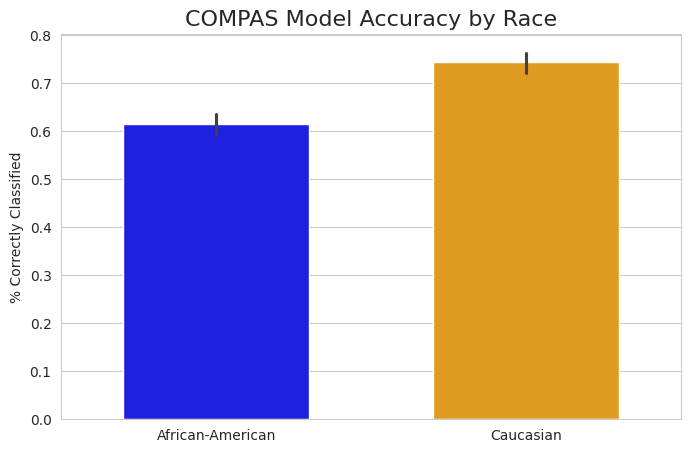

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(data=fairness_df, x="race", y="correct", width=0.6,palette=["blue", "orange"])
plt.title("COMPAS Model Accuracy by Race", fontsize=16)
plt.xlabel(None)
plt.ylabel("% Correctly Classified")
plt.show()

Visualiza qué proporción de acusados de cada grupo racial fue clasificado como
de riesgo medio o alto por COMPAS.

Permite detectar si el modelo predice riesgo alto con mayor frecuencia para
un grupo racial específico.

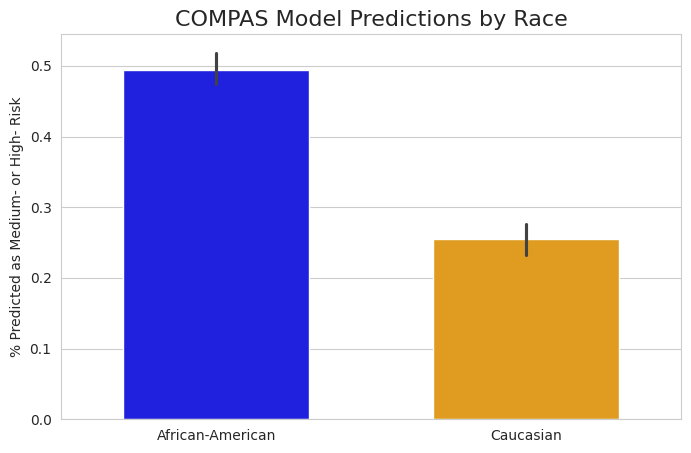

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=fairness_df, x="race", y="predicted_recid", width=0.6,palette=["blue", "orange"])
plt.title("COMPAS Model Predictions by Race", fontsize=16,)
plt.xlabel(None)
plt.ylabel("% Predicted as Medium- or High- Risk")
plt.show()

Cómo difiere la reincidencia real por raza:

En los grafos:

- **Arriba**:  Falsos negativos por raza. Tasa de reincidencia real entre quienes fueron clasificados como *bajo riesgo* (`predicted_recid=0`).
- **Abajo**: Verdaderos positivos por raza. Tasa de reincidencia real entre quienes fueron clasificados como *riesgo medio/alto* (`predicted_recid=1`) .



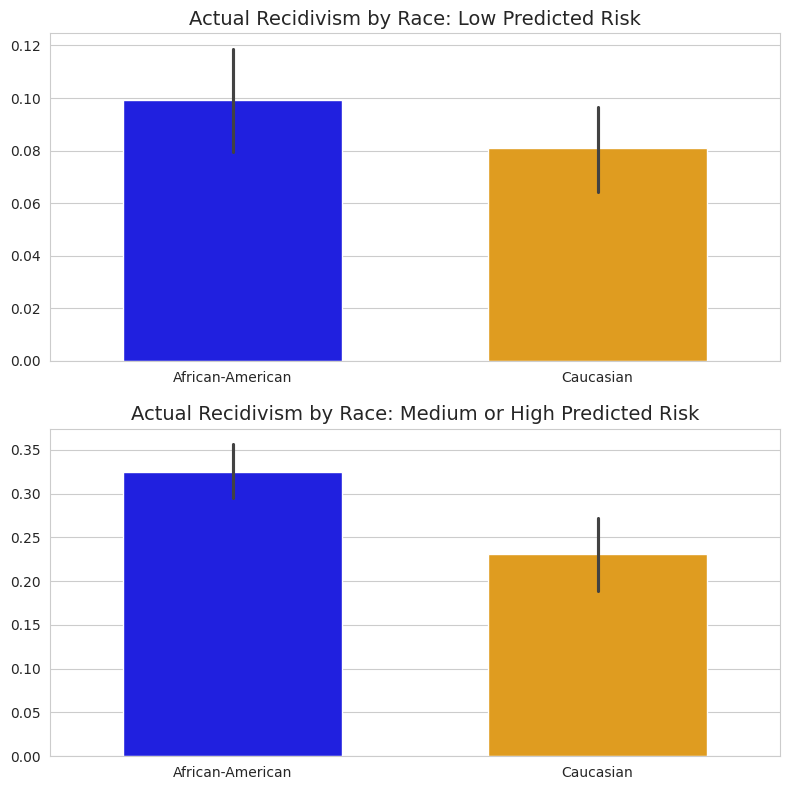

In [16]:
fig, ax = plt.subplots(nrows=2, figsize=(8, 8)) ### crea una figura con múltiples ejes (subplots).

sns.barplot(data=fairness_df[fairness_df['predicted_recid'] == 0],
            x="race", y="two_year_recid", width=0.6, ax=ax[0],palette=["blue", "orange"])
ax[0].set_title("Actual Recidivism by Race: Low Predicted Risk", fontsize=14)
ax[0].set_xlabel(None)
ax[0].set_ylabel(None)

sns.barplot(data=fairness_df[fairness_df['predicted_recid'] == 1],
            x="race", y="two_year_recid", width=0.6, ax=ax[1],palette=["blue", "orange"])
ax[1].set_title("Actual Recidivism by Race: Medium or High Predicted Risk", fontsize=14)
ax[1].set_xlabel(None)
ax[1].set_ylabel(None)

plt.tight_layout(h_pad=1.5) ### ajusta automáticamente el espaciado entre subplots.
plt.show()

Calcula la tasa promedio de aciertos del modelo COMPAS para cada grupo racial.


In [17]:
### .agg() sirve para aplicar una o varias funciones de resumen a columnas
fairness_df.groupby("race").agg({'correct':'mean'})

,correct
race,
African-American,0.615746
Caucasian,0.743660


Calcula qué proporción de acusados de cada grupo racial fue predicho como
de riesgo medio o alto.

In [18]:
fairness_df.groupby("race").agg({'predicted_recid':'mean'})

,predicted_recid
race,
African-American,0.494786
Caucasian,0.254969


## Disparidad en la tasa de clasificación correcta (Accuracy) del modelo


### Inferencia Causal

Usaremos la librería `dowhy` para plantear el problema como uno de inferencia causal.

https://www.pywhy.org/dowhy/main/user_guide/index.html

Define dos funciones auxiliares que convierten variables numéricas en
categorías ordinales, necesarias para el modelo

In [19]:
### clasifica el número de delitos juveniles '0', '1-2', '3+'.
def group_juvenile_offenses(count):
  if count == 0:
    return '0'
  elif count <= 2:
    return '1-2'
  else:
    return '3+'

### clasifica el número de condenas previas en cuatro grupos: `'0'`, `'1-3'`, `'4-8'`, `'9+'`.

def group_priors(count):
  if count == 0:
    return '0'
  elif count <= 3:
    return '1-3'
  elif count <= 8:
    return '4-8'
  else:
    return '9+'

fairness_df['juvenile_offenses_grouped'] = fairness_df['juvenile_offenses'].apply(group_juvenile_offenses)
fairness_df['priors_grouped'] = fairness_df['priors_count'].apply(group_priors)

Muestra cuántos acusados caen en cada categoría de delitos juveniles y
qué proporción fue predicha como riesgo medio/alto en cada grupo.

In [20]:
fairness_df.groupby('juvenile_offenses_grouped').agg({'predicted_recid':['count', 'mean']})

predicted_recid          
                                    count      mean
juvenile_offenses_grouped                          
0                                    3017  0.345376
1-2                                   277  0.732852
3+                                     83  0.915663

Muestra la distribución de acusados según el número de condenas previas (agrupadas)
y la tasa de predicción de riesgo en cada categoría.

Confirma que más condenas previas implica mayor tasa de predicción de riesgo alto.

In [21]:
fairness_df.groupby('priors_grouped', dropna=False).agg({'predicted_recid':['count', 'mean']})

predicted_recid          
                         count      mean
priors_grouped                          
0                         1293  0.253674
1-3                       1260  0.345238
4-8                        549  0.577413
9+                         275  0.876364

## DAG

Deinimos nuestro gráfico causal usando Graph Markup Language, con las siguientes variables

* X: raza
* Y: accuracy del modelo COMPAS
* Z1: género
* Z2: edad
* J: conteo de ofensas juveniles
* P: número de ofensas previas (prior offense count)
* D: grado / gravedad del cargo

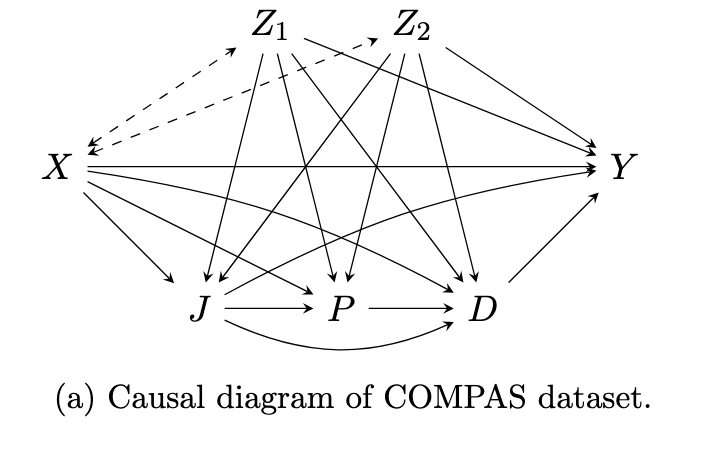

Define la estructura del Modelo Causal usando Graph Markup Language (GML).
Este grafo **codifica el conocimiento experto** sobre las relaciones causales entre las variables del dataset COMPAS:

- **`race`** (X): (tratamiento / atributo protegido) Es la variable cuyo efecto causal queremos medir sobre el outcome
- **`correct`** (Y): variable de resultado (outcome).
- **`sex`, `age_cat`** (Z): confounders.
- **`juvenile_offenses_grouped`, `priors_grouped`, `c_charge_degree`** (W): mediadores.

El grafo define tanto efectos directos:
* (`race → correct`)
como indirectos
* (`race → priors_grouped → correct`)

Alineado con el **Standard Fairness Model (SFM)**.

https://arxiv.org/abs/2207.11385

En este artículo se introduce el framework del análisis causal de fairness, se propone el Fairness Cookbook para evaluar impacto y trato disparejo, y culmina en el Fairness Map, que es el primer intento sistemático de organizar y explicar la relación entre distintos criterios de fairness de la literatura.

Ojo: La arista race --> correct es justamente la hipótesis que se quiere cuantificar.

In [22]:
causal_graph_accuracy = """
graph [
  comment "Causal graph for the COMPAS dataset"
  directed 1
  IsPlanar 1
  node [
    id "race"
    label "race"
  ]
  node [
    id "correct"
    label "correct"
  ]
  node [
    id "sex"
    label "sex"
  ]
  node [
    id "age_cat"
    label "age_cat"
  ]
  node [
    id "juvenile_offenses_grouped"
    label "juvenile_offenses_grouped"
  ]
  node [
    id "priors_grouped"
    label "priors_grouped"
  ]
  node [
    id "c_charge_degree"
    label "c_charge_degree"
  ]
  edge [
    source "race"
    target "correct"
    label "Discriminatory Effect"
  ]
  edge [
    source "race"
    target "juvenile_offenses_grouped"
    label "Edge from race to juvenile offense count"
  ]
  edge [
    source "race"
    target "priors_grouped"
    label "Edge from race to prior offense count"
  ]
  edge [
    source "race"
    target "c_charge_degree"
    label "Edge from race to charge degree"
  ]
  edge [
    source "sex"
    target "correct"
    label "Edge from sex to outcome"
  ]
  edge [
    source "sex"
    target "juvenile_offenses_grouped"
    label "Edge from sex to juvenile offense count"
  ]
  edge [
    source "sex"
    target "priors_grouped"
    label "Edge from sex to prior offense count"
  ]
  edge [
    source "sex"
    target "c_charge_degree"
    label "Edge from sex to charge degree"
  ]
  edge [
    source "age_cat"
    target "correct"
    label "Edge from age to outcome"
  ]
  edge [
    source "age_cat"
    target "juvenile_offenses_grouped"
    label "Edge from age to juvenile offense count"
  ]
  edge [
    source "age_cat"
    target "priors_grouped"
    label "Edge from age to prior offense count"
  ]
  edge [
    source "age_cat"
    target "c_charge_degree"
    label "Edge from age to charge degree"
  ]

  edge [
    source "juvenile_offenses_grouped"
    target "priors_grouped"
    label "Edge from juvenile count to prior count"
  ]
  edge [
    source "juvenile_offenses_grouped"
    target "c_charge_degree"
    label "Edge from juvenile count to charge degree"
  ]
  edge [
    source "juvenile_offenses_grouped"
    target "correct"
    label "Edge from juvenile count to outcome"
  ]
  edge [
    source "priors_grouped"
    target "c_charge_degree"
    label "Edge from prior count to charge degree"
  ]
  edge [
    source "c_charge_degree"
    target "correct"
    label "Edge from charge degree to outcome"
  ]
]
"""

La estructura de este grafo se alinea con el **Standard Fairness Model (SFM)** usando las variables del conjunto de datos COMPAS.

* **Atributo Protegido ($X$):** `race`
* **Resultado ($Y$):** `correct`
* **Confundidores ($Z$):** `sex`, `age_cat`
* **Mediadores ($W$):** `juvenile_offenses_grouped`, `priors_grouped`, `c_charge_degree`

Este grafo formaliza las suposiciones sobre cómo estos factores se influyen mutuamente. Por ejemplo, asume que la raza `race` puede tener un efecto directo en la precisión del modelo (`correct`), pero también un efecto indirecto a través de su influencia en factores como el número de condenas previas.

## Creación del mmodelo con DoWhy



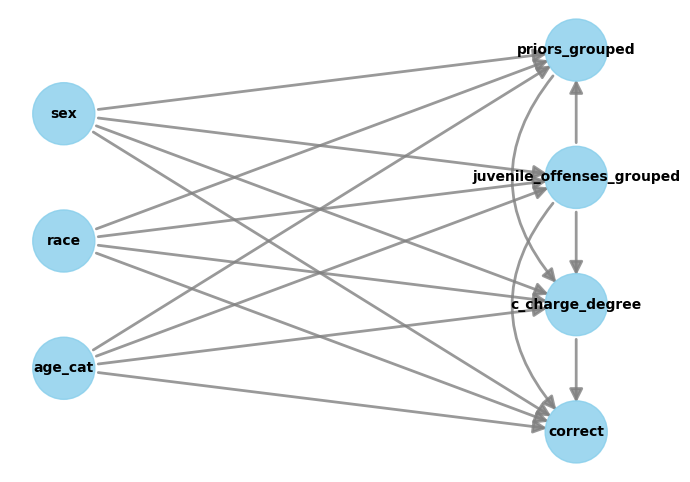

In [23]:
#necesitamos codificar la variable race:
causal_df = fairness_df\
  .assign(race=lambda x: x.race.map({'Caucasian':0, 'African-American':1}))

#Aquí estamos definiendo el modelo causal.
# Al especificar que el tratamiento es la variable "race" definimos cuál es la
# causa que queremos investigar. En el contexto de fairness, este es el atributo protegido

# outcome = "correct" --> cuál es el resultado o efecto que queremos

# medir. Al especificar graph=causal_graph_accuracy es donde se incorpora el
# conocimiento experto, el cual contiene las suposiciones sobre cómo las
# variables se relacionan entre sí.

causal_model_accuracy = CausalModel(data=causal_df, treatment="race", outcome="correct", graph=causal_graph_accuracy)
causal_model_accuracy.view_model() #sólo para ver el grafo

Identificación del efecto causal:

La función **`causal_model.identify_effect()`**: analiza el grafo causal y encuentra
  una estrategia de identificación (el "estimand"). Retorna:
  - El tipo de efecto a estimar: **ATE** (Average Treatment Effect).
  - El método de identificación: **Backdoor** (ajuste por confounders).
  - Las variables de ajuste necesarias para bloquear rutas traseras espurias.

En este caso, identifica que hay que controlar por `sex` y `age_cat` para
aislar el efecto causal directo de `race` sobre `correct`.


In [24]:
identified_estimand_accuracy = causal_model_accuracy.identify_effect()
print(identified_estimand_accuracy)

Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
   d               
───────(E[correct])
d[race]            
Estimand assumption 1, Unconfoundedness: If U→{race} and U→correct then P(correct|race,,U) = P(correct|race,)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
   d               
───────(E[correct])
d[race]            
Estimand assumption 1, Unconfoundedness: If U→{race} and U→correct then P(correct|race,,U) = P(correct|race,)



### **Explicación e Interpretaciones**

En el paso anterior, causal_model_accuracy.identify_effect() aún no calcula un número específico. Su objetivo es encontrar una fórmula estadística para medir el efecto causal. A esta "fórmula" o estrategia se le conoce como "Estimand".

* Además, nos indica que el objetivo es calcular el **Efecto Promedio del Tratamiento (ATE)**.

En nuestro contexto, lo que queremos saber es en promedio, **¿cuál es el impacto causal de la raza de un acusado en la exactitud del modelo?**

* La estrategia o método principal usado fue Ruta Trasera o **"Backdoor"** (la forma de identificación más común y robusta).

$$ \textrm{ Si } \,  U → {race} \textrm{ y } U → correct, \textrm{ entonces }P(correct|race,U) = P(correct|race)$$

Esto es la suposición de no confusión (unconfoundedness): dice que si existiera alguna variable no observada U que causara tanto race como correct, habría un problema. La suposición afirma que no existe tal U, o que al condicionar por las variables de ajuste (sex, age_cat) ese problema queda resuelto.

En nuestro caso, para aislar el efecto causal
$$race \rightarrow correct$$

necesitamos bloquear todos los backdoor paths (rutas traseras) que crean correlaciones falsas.

Por ejemplo, una ruta trasera es $$race \leftarrow age \rightarrow correct$$
La edad (age_cat) es un confounder que influye tanto en la demografía racial de los acusados como en el resultado. La estrategia "backdoor" consiste en "ajustar por" o "controlar" estos confundidores (age_cat y sex) para cerrar estas rutas y aislar el efecto real.

La Expresión: `d/d[race](E[correct])` es una manera formal para expresar la pregunta causal: "¿Cómo cambia el valor esperado de `correct` si pudiéramos **intervenir** y cambiar el valor de `race`?". Esto es es lo que lo hace distinto de una simple correlación.



In [25]:
#Aquí es donde se calcula el efecto causal. Le pasamos identified_estimand_accuracy
# del paso anterior.

# Además, especificamos el método para la estimación
estimate_accuracy = causal_model_accuracy.estimate_effect(
    identified_estimand_accuracy,
    control_value=0,
    treatment_value=1,
    method_name="backdoor.generalized_linear_model",
    method_params={'glm_family':statsmodels.api.families.Binomial()}
)

estimate_accuracy.value

np.float64(-0.11602012172673581)

`correct` es 0 o 1, así que no tiene sentido asumir que sigue una distribución normal. La familia Binomial con función de enlace logit es la apropiada:

$$\log\left(\frac{P(correct=1)}{1 - P(correct=1)}\right) = \beta_0 + \beta_1 \cdot race + \beta_2 \cdot sex + \ldots$$

Esto garantiza que las predicciones del modelo siempre estén entre 0 y 1, como debe ser para una probabilidad.

Calcula y muestra el intervalo de confianza de la estimación causal.

- **`estimate.get_confidence_intervals()`**: retorna los límites inferior y superior]
  del intervalo de confianza (por defecto al 95%) para el ATE estimado.

Si el intervalo no incluye el 0, el efecto causal es estadísticamente significativo.

In [26]:
estimate_accuracy.get_confidence_intervals()

(-0.15039889412601593, -0.08507783867039997)

Evalúa si el efecto causal estimado es estadísticamente significativo.

- **`estimate.test_stat_significance()`**: realiza un test estadístico (z-test o t-test)
  sobre el ATE y retorna el p-valor y la estadística de prueba.

Un p-valor < 0.05 indica que la diferencia causal observada es poco probable
que sea producto del azar.

In [27]:
estimate_accuracy.test_stat_significance()

{'p_value': (0, 0.001)}

La interpretación es: si race no tuviera ningún efecto causal real sobre correct, la probabilidad de observar un efecto tan grande como el estimado solo por azar sería menor al 0.1%.

Lo que implica en este contexto
Hay evidencia estadística fuerte de que la raza tiene un efecto causal sobre la precisión del modelo COMPAS. Es decir, el modelo no comete errores al azar de forma equitativa entre grupos raciales, sino que la raza explica sistemáticamente parte de esa diferencia en precisión.

Lo que el p-value NO dice:
Tres cosas importantes que frecuentemente se confunden:

No dice el tamaño del efecto. Un p-value muy pequeño puede venir de un efecto causal pequeño pero medido con muchos datos. Hay que mirar el ATE para saber si la diferencia es grande o pequeña en términos prácticos.
No prueba causalidad por sí solo. La significancia estadística asume que el modelo causal (el grafo GML) está bien especificado. Si el grafo es incorrecto, el p-value no tiene la interpretación causal que se le quiere dar.
No dice nada sobre confundidores no observados. Si hay variables ocultas que el grafo no captura, el resultado podría estar sesgado aunque el p-value sea pequeño.



- **`estimate.interpret()`**: imprime una descripción textual del ATE, incluyendo
  el método utilizado, el valor estimado y su interpretación en el contexto del
  problema definido (tratamiento y outcome).

In [28]:
estimate_accuracy.interpret()

Increasing the treatment variable(s) [race] from 0 to 1 causes an increase of -0.11602012172673581 in the expected value of the outcome [['correct']], over the data distribution/population represented by the dataset.


El `-0.116` es el **Efecto Promedio del Tratamiento (ATE)**, que podemos interpretar de la siguiente manera:

"Después de "bloquear" estadísticamente la influencia de los confounders (edad y sexo), el ser un acusado Afroamericano en lugar de Caucásico **causa una disminución promedio de 0.116 en la probabilidad de que la predicción del modelo sea correcta**.

Dicho de otra forma el modelo es, en promedio, **11.6 puntos porcentuales menos preciso** para los acusados Afroamericanos que para los acusados Caucásicos que son estadísticamente similares en edad y sexo. Es una medida del sesgo del modelo.